,model,accuracy,avg_time
3,unsloth/mistral-7b-instruct-v0.3-bnb-4bit,29.28,1.77
1,unsloth/granite-3.2-8b-instruct-bnb-4bit,38.43,2.28
4,unsloth/Qwen2.5-7B-Instruct-bnb-4bit,55.24,3.14
2,unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit,45.62,3.64
0,unsloth/gemma-3-12b-it-bnb-4bit,57.78,5.88


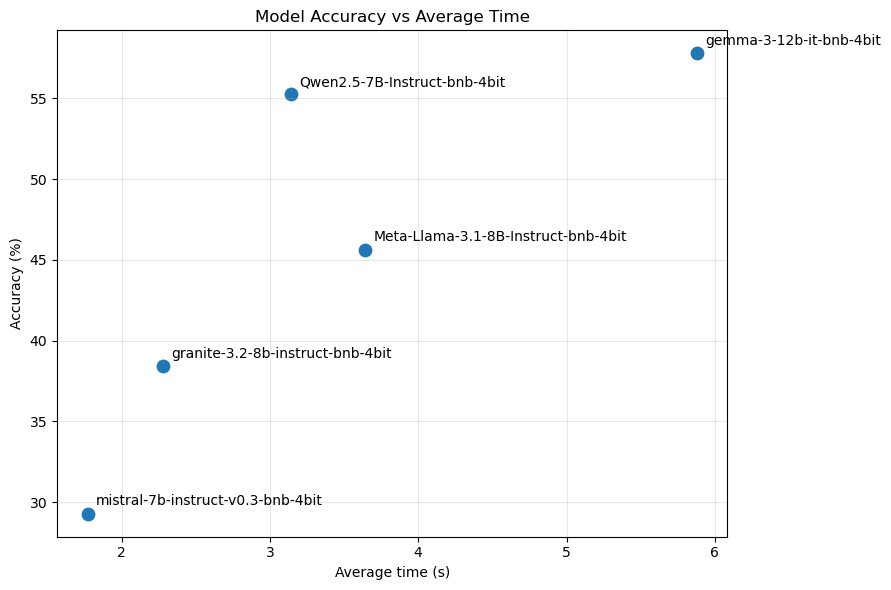

In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = Path.cwd()
summary_paths = sorted(base_dir.glob("single_results_summary*.txt"))

rows = []
for path in summary_paths:
    text = path.read_text(encoding="utf-8")
    model_match = re.search(r"Model used:\s*(.+)", text)
    acc_match = re.search(r"Accuracy:\s*([0-9.]+)%", text)
    time_match = re.search(r"Average time:\s*([0-9.]+)s", text)

    if model_match and acc_match and time_match:
        rows.append(
            {
                "model": model_match.group(1).strip(),
                "accuracy": float(acc_match.group(1)),
                "avg_time": float(time_match.group(1)),
            }
        )

if not rows:
    raise ValueError("No model summaries were parsed. Ensure the notebook is run from slm_results/final_datasets.")

df = pd.DataFrame(rows).sort_values("avg_time")
display(df)

plt.figure(figsize=(9, 6))
plt.scatter(df["avg_time"], df["accuracy"], s=80)

for _, row in df.iterrows():
    label = row["model"].split("/")[-1]
    plt.annotate(label, (row["avg_time"], row["accuracy"]), xytext=(6, 6), textcoords="offset points")

plt.xlabel("Average time (s)")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy vs Average Time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [2]:

START_RE = re.compile(r'^\d+,[^,]*,')

def load_wrapped_csv(path: str) -> pd.DataFrame:
    records = []
    cur = None

    with open(path, "r", encoding="utf-8", errors="replace") as f:
        _ = next(f)  # skip header
        for raw in f:
            line = raw.rstrip("\r\n")
            if START_RE.match(line):
                if cur is not None:
                    records.append(cur)
                cur = line
            else:
                if cur is not None:
                    cur += " " + line.strip()
        if cur is not None:
            records.append(cur)

    rows = []
    for rec in records:
        left, correct, t, cat = rec.rsplit(",", 3)
        qid, model_answer, question = left.split(",", 2)
        question = question.strip()
        if len(question) >= 2 and question[0] == '"' and question[-1] == '"':
            question = question[1:-1].replace('""', '"')

        rows.append({
            "QID": qid.strip(),
            "model_answer": model_answer.strip(),
            "question": question,
            "correct_answer": correct.strip(),
            "time": t.strip(),
            "category": cat.strip(),
        })

    df = pd.DataFrame(rows)
    df["QID"] = pd.to_numeric(df["QID"], errors="coerce").astype("Int64")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")
    return df


In [3]:
gemma   = load_wrapped_csv("single_results_unsloth_gemma-3-12b-it-bnb-4bit.csv")
granite = load_wrapped_csv("single_results_unsloth_granite-3.2-8b-instruct-bnb-4bit.csv")
llama   = load_wrapped_csv("single_results_unsloth_Meta-Llama-3.1-8B-Instruct-bnb-4bit.csv")
mistral = load_wrapped_csv("single_results_unsloth_mistral-7b-instruct-v0.3-bnb-4bit.csv")
qwen    = load_wrapped_csv("single_results_unsloth_Qwen2.5-7B-Instruct-bnb-4bit_prompt1.csv")


Mean accuracy by category (fraction):


,Gemma 12B,Granite 8B,Meta 8B,Mistral 7B,Qwen 7B
category,,,,,
biology,0.7657,0.6234,0.6625,0.5704,0.7183
business,0.6286,0.3777,0.4740,0.2674,0.6337
chemistry,0.5610,0.2915,0.3922,0.1952,0.5565
computer science,0.6366,0.4000,0.4756,0.2927,0.5341
economics,0.6908,0.4704,0.5569,0.4206,0.6469
engineering,0.3426,0.2828,0.2652,0.1847,0.4004
health,0.5733,0.4193,0.5770,0.3533,0.5477
history,0.5302,0.3911,0.4173,0.3412,0.4226
law,0.3778,0.2752,0.2934,0.2116,0.3079


Overall mean accuracy by model (fraction):
Gemma 12B     0.5822
Qwen 7B       0.5462
Meta 8B       0.4644
Granite 8B    0.3968
Mistral 7B    0.3106
dtype: float64


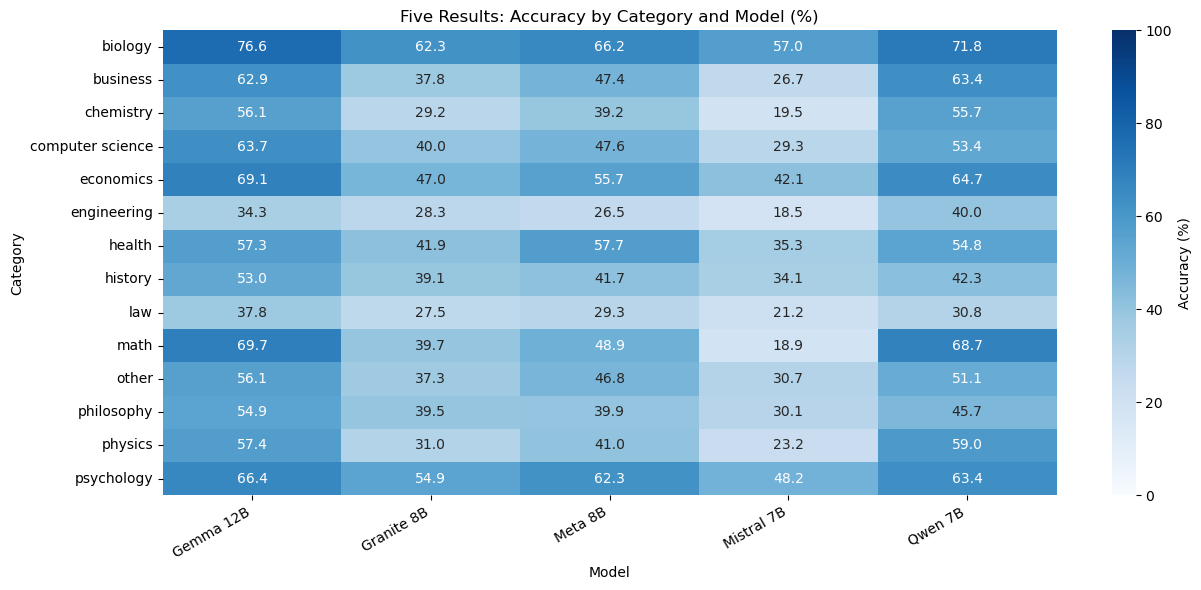

In [5]:
# Compare category accuracy (14 categories) across the 6 models in five_results

gemma_accuracy = []
for i, row in gemma.iterrows():
    correct = row["model_answer"].strip().lower() == row["correct_answer"].strip().lower()
    if correct:
        gemma_accuracy.append(1)
    else:
        gemma_accuracy.append(0)
gemma_print = gemma.copy()
gemma_print["accuracy"] = gemma_accuracy

granite_accuracy = []
for i, row in granite.iterrows():    
    correct = row["model_answer"].strip().lower() == row["correct_answer"].strip().lower()
    if correct:
        granite_accuracy.append(1)
    else:
        granite_accuracy.append(0)
granite_print = granite.copy()
granite_print["accuracy"] = granite_accuracy
llama_accuracy = []
for i, row in llama.iterrows():    
    correct = row["model_answer"].strip().lower() == row["correct_answer"].strip().lower()
    if correct:
        llama_accuracy.append(1)
    else:
        llama_accuracy.append(0)
llama_print = llama.copy()
llama_print["accuracy"] = llama_accuracy
mistral_accuracy = []
for i, row in mistral.iterrows():    
    correct = row["model_answer"].strip().lower() == row["correct_answer"].strip().lower()
    if correct:
        mistral_accuracy.append(1)
    else:
        mistral_accuracy.append(0)
mistral_print = mistral.copy()
mistral_print["accuracy"] = mistral_accuracy
qwen_accuracy = []
for i, row in qwen.iterrows():    
    correct = row["model_answer"].strip().lower() == row["correct_answer"].strip().lower()
    if correct:
        qwen_accuracy.append(1)
    else:
        qwen_accuracy.append(0)
qwen_print = qwen.copy()
qwen_print["accuracy"] = qwen_accuracy
model_frames = {
    'Gemma 12B': gemma_print,
    'Granite 8B': granite_print,
    'Meta 8B': llama_print,
    'Mistral 7B': mistral_print,
    'Qwen 7B': qwen_print,
}



category_accuracy = pd.DataFrame({
    model: df.groupby('category')['accuracy'].mean()
    for model, df in model_frames.items()
}).sort_index()

print('Mean accuracy by category (fraction):')
display(category_accuracy.round(4))

overall_mean = category_accuracy.mean(axis=0).sort_values(ascending=False)
print('Overall mean accuracy by model (fraction):')
print(overall_mean.round(4))

plt.figure(figsize=(13, 6))
sns.heatmap(
    category_accuracy * 100,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Accuracy (%)'}
)
plt.title('Five Results: Accuracy by Category and Model (%)')
plt.xlabel('Model')
plt.ylabel('Category')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()





In [ ]:
# Do a 80% vote on each question across the 5 models, get an accuracy, and then label it complex = 1 if accuracy < 0.8 and complex = 0 if accuracy >= 0.8, then see how many questions are complex vs simple.
all_models = [gemma, granite, llama, mistral, qwen]

final_dataset = ["QID", "question", "correct_answer", "category", "complex"]
final_rows = []
for qid in gemma["QID"].unique():
    qid_rows = []
    for model in all_models:
        row = model[model["QID"] == qid]
        if not row.empty:
            qid_rows.append(row.iloc[0])
    if len(qid_rows) == 5:
        question = qid_rows[0]["question"]
        correct_answer = qid_rows[0]["correct_answer"]
        category = qid_rows[0]["category"]
        accuracies = []
        for row in qid_rows:
            correct = row["model_answer"].strip().lower() == row["correct_answer"].strip().lower()
            accuracies.append(1 if correct else 0)
        accuracy_fraction = sum(accuracies) / len(accuracies)
        complex_label = 1 if accuracy_fraction < 0.8 else 0
        final_rows.append({
            "QID": qid,
            "question": question,
            "correct_answer": correct_answer,
            "category": category,
            "complex": complex_label,
            "accuracy_fraction": accuracy_fraction,
        })

final_df = pd.DataFrame(final_rows)
print('Final dataset with complexity labels:')
display(final_df.head())
print('Complex vs Simple question counts:')
print(final_df["complex"].value_counts())
print("Accuracy: ", final_df["complex"].value_counts()[0] / len(final_df))

# final_df.to_csv("final_dataset_with_complexity.csv", index=False)

Final dataset with complexity labels:


,QID,question,correct_answer,category,complex,accuracy_fraction
0,70,"Typical advertising regulatory bodies suggest,...",I,business,1,0.4
1,71,Managers are entrusted to run the company in t...,F,business,0,0.8
2,72,There are two main issues associated with ____...,J,business,1,0.6
3,73,_______ locate morality beyond the sphere of r...,C,business,1,0.0
4,74,Some of key differences between Islamic finan...,G,business,1,0.2


Complex vs Simple question counts:
complex
1    8755
0    3277
Name: count, dtype: int64
Accuracy:  0.27235704787234044
